In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('cancer.csv')

In [3]:
df[:4]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,is_cancer
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.shape

(569, 31)

In [6]:
df_y = df.pop('is_cancer')
df_y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_cancer, dtype: int64

In [7]:
df.shape

(569, 30)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [9]:
model = LogisticRegression(random_state=42)
model.fit(df, df_y)
pred_y = model.predict(df)
score = f1_score(df_y, pred_y)
print('F1 score', score)

F1 score 0.9584487534626038


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [11]:
df[:3]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [13]:
pca = PCA(n_components=2)
pca.fit(scaled_data)

PCA(n_components=2)

In [14]:
x_pca = pca.transform(scaled_data)

In [15]:
scaled_data.shape

(569, 30)

In [16]:
x_pca

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In [17]:
type(x_pca)

numpy.ndarray

In [18]:
pd.DataFrame(x_pca).head()

,0,1
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


In [19]:
## No PCA

In [20]:
model = LogisticRegression(random_state=42)
model.fit(scaled_data, df_y)
pred_y = model.predict(scaled_data)
score = f1_score(df_y, pred_y)
print('F1 score', score)

F1 score 0.9902370990237099


## Modeling with PCA = 2

In [22]:
model = LogisticRegression(random_state=42)
model.fit(x_pca, df_y)
pred_y = model.predict(x_pca)
score = f1_score(df_y, pred_y)
print('F1 score', score)

F1 score 0.9652294853963839


In [61]:
pca = PCA()
pca.fit(scaled_data)

PCA()

In [63]:
pca.explained_variance_

array([1.33049908e+01, 5.70137460e+00, 2.82291016e+00, 1.98412752e+00,
       1.65163324e+00, 1.20948224e+00, 6.76408882e-01, 4.77456255e-01,
       4.17628782e-01, 3.51310875e-01, 2.94433153e-01, 2.61621161e-01,
       2.41782421e-01, 1.57286149e-01, 9.43006956e-02, 8.00034045e-02,
       5.95036135e-02, 5.27114222e-02, 4.95647002e-02, 3.12142606e-02,
       3.00256631e-02, 2.74877113e-02, 2.43836914e-02, 1.80867940e-02,
       1.55085271e-02, 8.19203712e-03, 6.91261258e-03, 1.59213600e-03,
       7.50121413e-04, 1.33279057e-04])

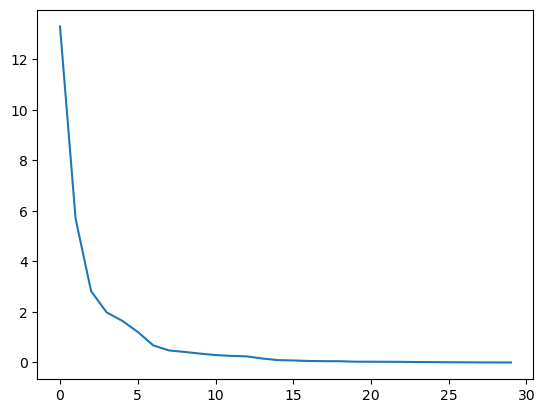

In [65]:
plt.plot(pca.explained_variance_)

Text(0, 0.5, 'Cumulative Variance')

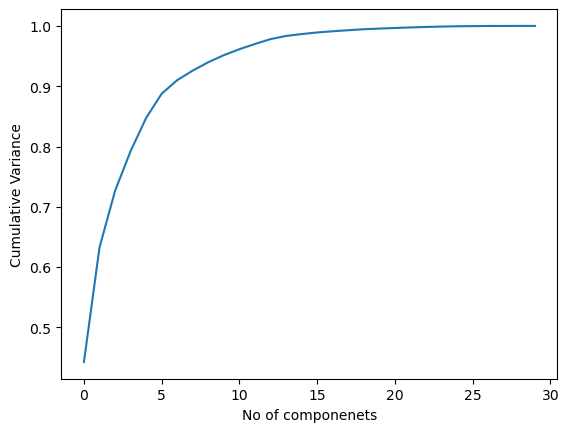

In [71]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('No of componenets')
plt.ylabel('Cumulative Variance')

In [120]:
pca = PCA(n_components= 5)
pca.fit(scaled_data)
x_pca = pca.transform(scaled_data)

model = LogisticRegression(random_state=42)
model.fit(x_pca, df_y)
pred_y = model.predict(x_pca)
score = f1_score(df_y, pred_y)
print('F1 score', score)

F1 score 0.9805013927576601


In [124]:
0.99 - 0.98

0.010000000000000009

In [126]:
x_pca

array([[ 9.19283683,  1.94858307, -1.12316615,  3.63373082, -1.19511026],
       [ 2.3878018 , -3.76817174, -0.5292927 ,  1.11826397,  0.62177519],
       [ 5.73389628, -1.0751738 , -0.55174758,  0.91208257, -0.17708613],
       ...,
       [ 1.25617928, -1.90229671,  0.56273052, -2.08922699,  1.8099914 ],
       [10.37479406,  1.67201011, -1.87702933, -2.35603115, -0.03374196],
       [-5.4752433 , -0.67063679,  1.4904431 , -2.2991573 , -0.18470365]])

In [128]:
pca.explained_variance_ratio_

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768])

In [130]:
sum(pca.explained_variance_ratio_)

0.84734274316785